In [1]:
print("Hello")

Hello


In [2]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
) 

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 72147)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 63036)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 38951)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 24447)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 8476)

# #### Device() ####
# device = cuda:6

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:6)
# edge_attr                (32464, 16)              Tensor (cuda:6)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:6)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path             

---

In [3]:
from modules.train import Loader
from modules.data import GraphDataset

from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict

# typing
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch


In [4]:
def load_model(model, state_dict_path:str, device:str, dataset:GraphDataset|None=None, batch_size:int=128):
    # init with loader
    init_fn = getattr(model, 'init_with_loader', None)
    if callable(init_fn) and dataset is not None:
        loader = Loader(dataset, device=device, batch_size=batch_size)
        init_fn(loader)

    # load state dict
    state_dict = torch.load(state_dict_path, map_location=device)
    model.load_state_dict(state_dict)

    # set model to eval
    model.eval()   

class ModelOut2():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out) 

---

In [5]:
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
from modules.train import MultiTrainer, MultiTrainerStage, Experiment, grid, Loader
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss, KLDLoss, MultiLoss

import torch
import torch.nn as nn
from functools import partial

# multihead model
model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    # head_dim = None (default)
    # num_heads = 1 (default)
    method = 'set',

    # layers
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    mlp = False,
    variational = True,
    # out_module = nn.Linear (default)

    # layer params
    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 
    end_fn = False,

    # kwargs
    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
    # pooling_kwargs = None (default)
)

load_model(
    model=model,
    state_dict_path='output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/pathway_vae_trial_0_model.pth',
    device=device,
    dataset=dataset,
)

vals = ModelOut2(model, dataset, need_weights=True)

---
# names

In [6]:
import pandas as pd

In [7]:
pnames = pd.read_csv(dataset_dir/'other'/'pathway_names.csv')
plabels = [s.replace('path:', '') for s in dataset.wrapper.pathway_labels]
pathway_names = pnames.set_index('entry').loc[plabels, 'name'].to_list()
pathway_names = [s.replace(' - Homo sapiens (human)', '') for s in pathway_names]

---
# viz

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
def split_by_class(x, cls):
    out = {int(c): x[cls == c].mean(dim=0).mean(dim=1).tolist() for c in cls.unique()}
    out['Total'] = x.mean(dim=0).mean(dim=1).tolist()
    return out

In [10]:
print(dict_summary(vals.out['layer_outs']))

# ne                       0                        dict
# np                       1                        dict
# lp_ae                    1                        dict
# lp_cl                    1                        dict
# out_ae                   0                        dict
# out_cl                   0                        dict



In [11]:
ae = {}
cl = {}

# node to set attn
np = vals.out['layer_outs']['np']['attn'] # 1172,4373,305

# set to sample attn
ae['lp'] = vals.out['layer_outs']['lp_ae']['attn'].squeeze() # 1172,305,1 -> 1172,305
cl['lp'] = vals.out['layer_outs']['lp_cl']['attn'].squeeze() # 1172,305,1 -> 1172,305

# elementwise product to get joint attention
ae['joint'] = ae['lp'].unsqueeze(1) * np # 1172,4373,305
cl['joint'] = cl['lp'].unsqueeze(1) * np # 1172,4373,305

---

In [12]:
import numpy as np
import seaborn as sns

In [13]:
def split_by_class(data, classes):
    return {int(c): data[classes == c] for c in torch.unique(classes)}

In [14]:
ae['split'] = split_by_class(ae['joint'], vals.y)
cl['split'] = split_by_class(cl['joint'], vals.y)

In [15]:
ae['split'][0].mean(dim=0).shape

torch.Size([4373, 305])

<Axes: >

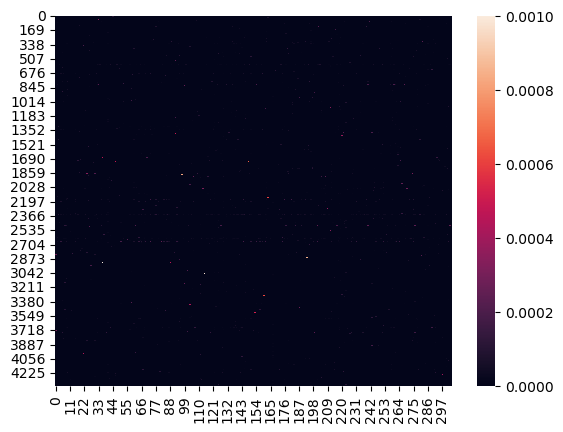

In [16]:
sns.heatmap(ae['split'][0].mean(dim=0), vmax=0.001)

In [17]:
ae['pw'] = {i: ae['split'][i].mean(dim=0).sum(dim=0).tolist() for i in ae['split']}
cl['pw'] = {i: cl['split'][i].mean(dim=0).sum(dim=0).tolist() for i in cl['split']}

In [18]:
ae['gene'] = {i: ae['split'][i].mean(dim=0).sum(dim=1).tolist() for i in ae['split']}
cl['gene'] = {i: cl['split'][i].mean(dim=0).sum(dim=1).tolist() for i in cl['split']}

,Basal,Her2,LumA,LumB,Solid Tissue Normal,n,micro_avg
ACTB,8.046307e-03,1.653072e-02,8.932425e-03,6.267677e-03,1.598704e-03,24.0,8.275167e-03
ADCY9,8.546959e-03,1.701897e-02,5.117721e-03,6.063171e-03,3.726821e-03,48.0,8.094728e-03
GLS,2.372083e-02,3.687299e-03,3.699537e-03,4.803543e-03,1.457480e-03,5.0,7.473738e-03
LAMA2,3.972954e-03,2.330304e-03,1.593159e-02,1.982697e-03,1.051927e-02,6.0,6.947362e-03
LAMA1,1.032361e-02,3.620604e-03,8.692020e-03,3.259618e-03,7.833984e-03,6.0,6.745967e-03
...,...,...,...,...,...,...,...
SRSF7,4.669547e-07,4.804753e-07,8.111855e-07,3.150082e-07,4.900755e-07,1.0,5.127398e-07
ZNF530,6.430137e-07,1.563479e-07,8.337558e-07,8.094480e-07,1.034152e-07,1.0,5.091961e-07
ZNF184,5.050300e-07,3.454222e-07,6.023145e-07,3.790456e-07,4.616747e-07,1.0,4.586974e-07
ZNF473,3.649984e-07,6.731255e-07,5.808770e-07,2.814997e-07,3.111849e-07,1.0,4.423371e-07


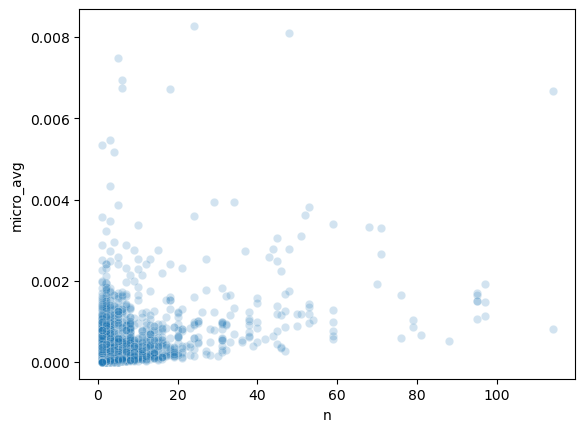

In [31]:
df2 = pd.DataFrame(cl['gene'])
df2 = df2.rename(columns=dict(enumerate(dataset.wrapper.y_labels)))
df2.index = dataset.wrapper.x_labels
df2['n'] = dataset.wrapper.pathway_index.sum(axis=1).tolist()
df2['micro_avg'] = df2[dataset.wrapper.y_labels].mean(axis=1)
display(df2.sort_values(by='micro_avg', ascending=False))#.head(50))

sns.scatterplot(x='n', y='micro_avg', data=df2, alpha=0.2)
# plt.xlim(0, 60)
# plt.ylim(-0.0001, 0.003)
plt.show()


<Axes: >

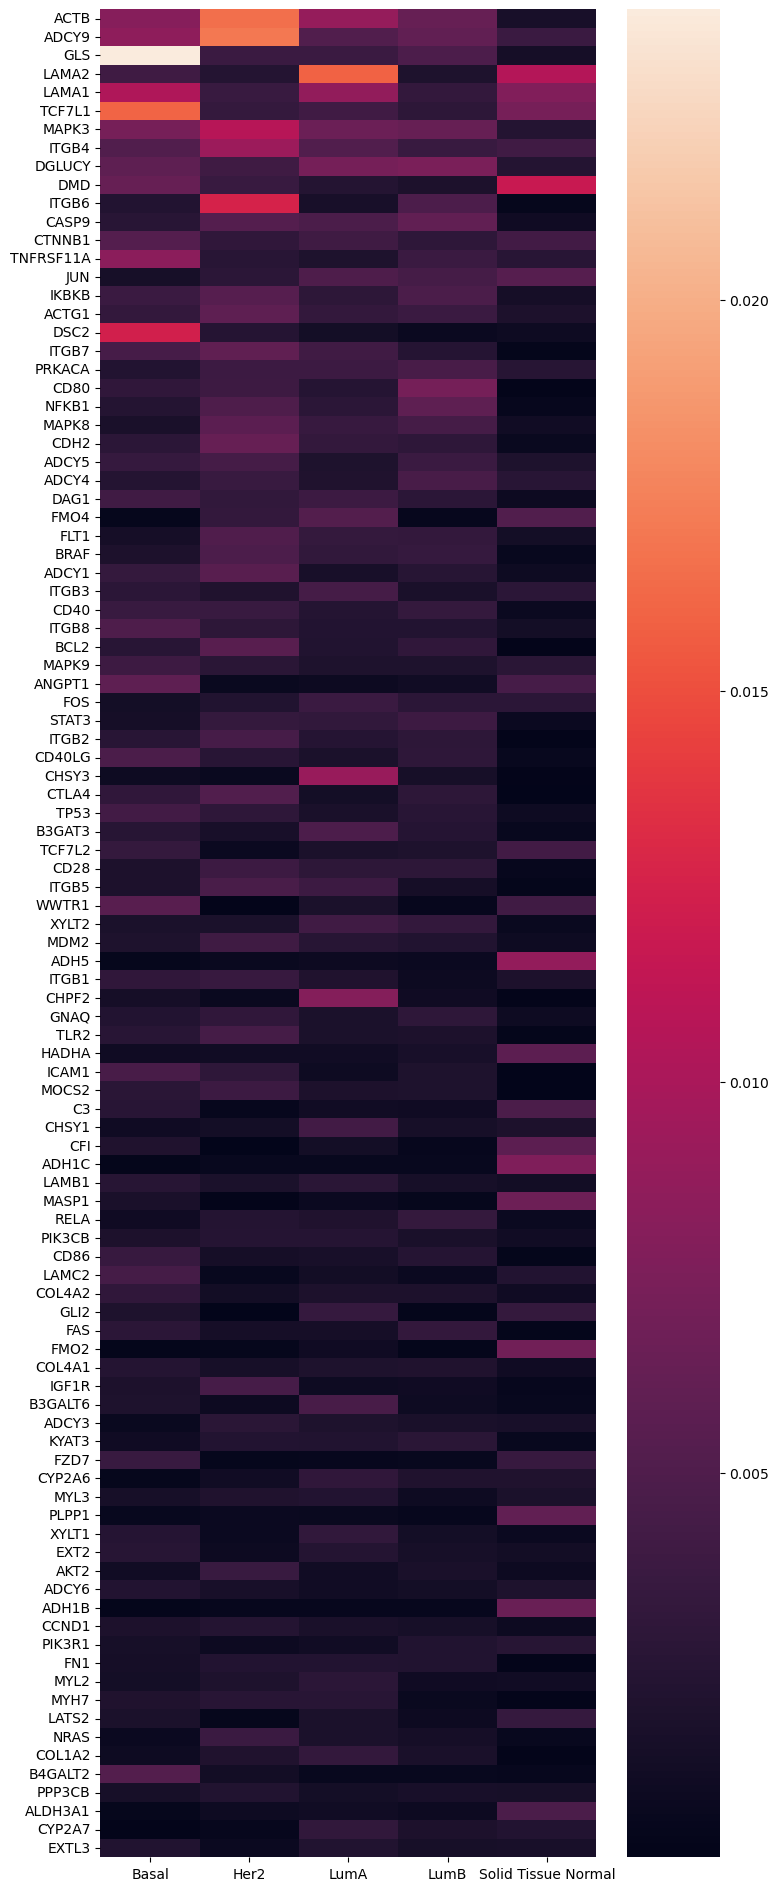

In [20]:
plt.figure(figsize=(8,24))
sns.heatmap(df2.sort_values(by='micro_avg', ascending=False)[dataset.wrapper.y_labels].head(100))

,Basal,Her2,LumA,LumB,Solid Tissue Normal,n,micro_avg
ECM-receptor interaction,0.068290,0.032837,0.060636,0.040646,0.039647,44.0,0.048411
Hypertrophic cardiomyopathy,0.050079,0.075654,0.054519,0.032238,0.027151,16.0,0.047928
Arrhythmogenic right ventricular cardiomyopathy,0.047924,0.021097,0.033414,0.013964,0.024553,14.0,0.028190
Rheumatoid arthritis,0.032757,0.034302,0.024939,0.029217,0.018914,16.0,0.028026
Basal cell carcinoma,0.072633,0.004638,0.011812,0.004308,0.039682,49.0,0.026614
...,...,...,...,...,...,...,...
Fc gamma R-mediated phagocytosis,0.000669,0.001127,0.001035,0.001373,0.000352,79.0,0.000911
JAK-STAT signaling pathway,0.000673,0.001134,0.001030,0.001372,0.000345,36.0,0.000911
Neutrophil extracellular trap formation,0.000667,0.001122,0.001037,0.001374,0.000344,57.0,0.000909
Intestinal immune network for IgA production,0.000661,0.001116,0.001040,0.001376,0.000344,18.0,0.000907


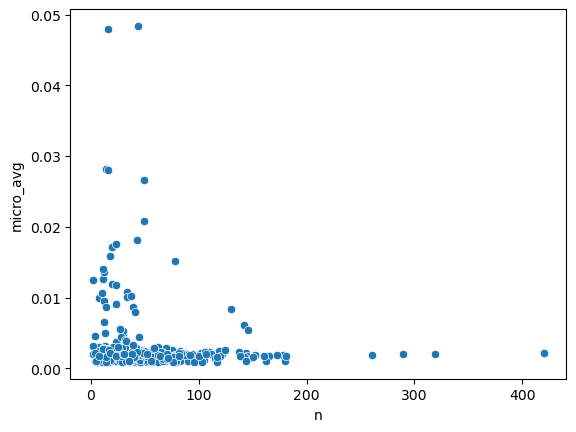

In [21]:
df = pd.DataFrame(cl['pw'])
df = df.rename(columns=dict(enumerate(dataset.wrapper.y_labels)))
df.index = pathway_names
df['n'] = dataset.wrapper.pathway_index.sum(axis=0).tolist()
df['micro_avg'] = df[dataset.wrapper.y_labels].mean(axis=1)
display(df.sort_values(by='micro_avg', ascending=False))

sns.scatterplot(x='n', y='micro_avg', data=df)
# plt.xlim(0, 200)
# plt.ylim(0, 0.005)
plt.show()

<Axes: >

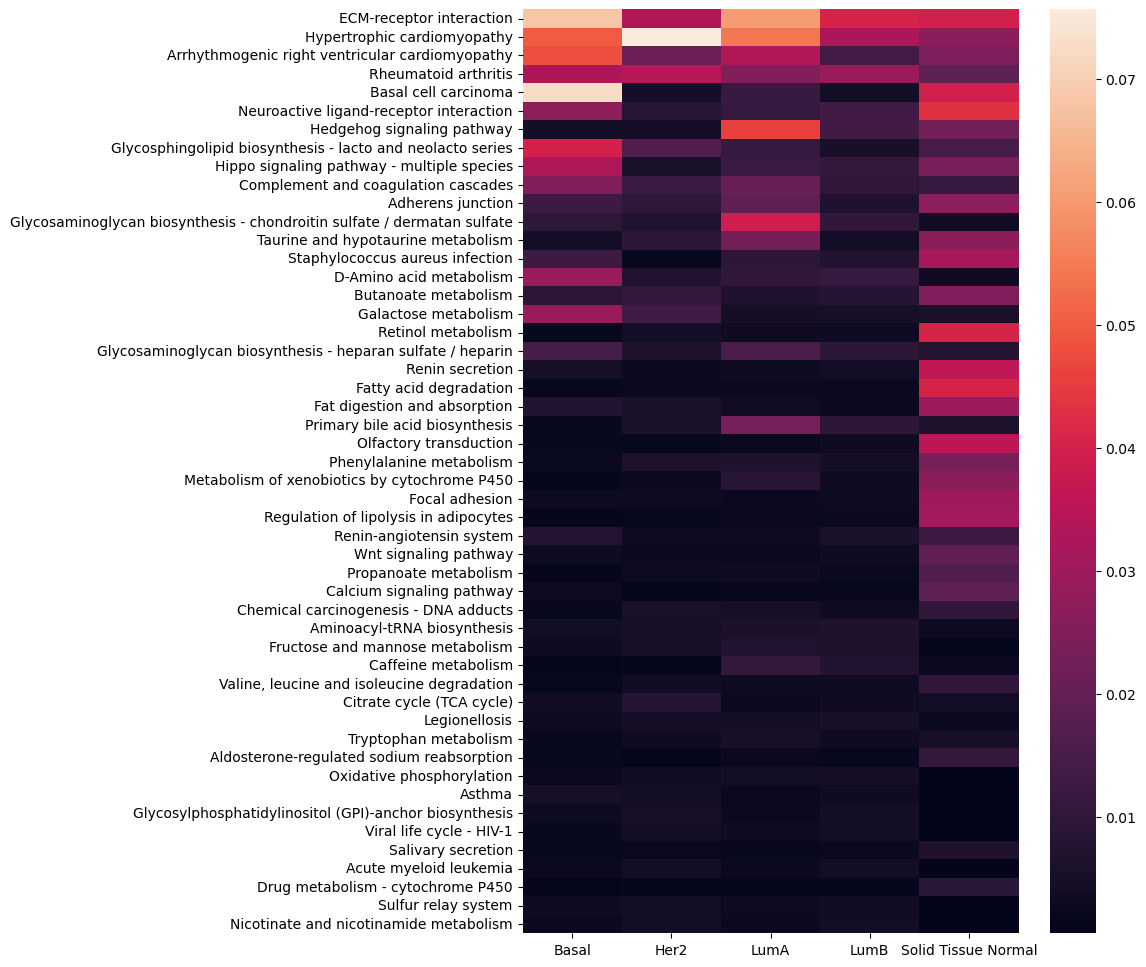

In [22]:
plt.figure(figsize=(8,12))
sns.heatmap(df.sort_values(by='micro_avg', ascending=False)[dataset.wrapper.y_labels].head(50))

---

In [23]:
df[['n']].values.shape

(305, 1)

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# df must contain:
# df["n"] = pathway size
# df["attention"] = raw attention score

X = df[["n"]].values
y = df["micro_avg"].values

model = LinearRegression()
model.fit(X, y)
df["resid"] = df["micro_avg"] - model.predict(X)
df

,Basal,Her2,LumA,LumB,Solid Tissue Normal,n,micro_avg,resid
Fat digestion and absorption,0.007475,0.006024,0.004043,0.002651,0.029587,8.0,0.009956,0.005846
MAPK signaling pathway,0.001640,0.002547,0.001926,0.002805,0.000695,261.0,0.001923,0.001935
JAK-STAT signaling pathway,0.000673,0.001134,0.001030,0.001372,0.000345,36.0,0.000911,-0.002743
Cocaine addiction,0.001633,0.002906,0.002032,0.003293,0.000706,28.0,0.002114,-0.001671
Colorectal cancer,0.001552,0.002860,0.001905,0.002798,0.000691,67.0,0.001961,-0.001188
...,...,...,...,...,...,...,...,...
B cell receptor signaling pathway,0.001115,0.001830,0.001513,0.002125,0.000515,72.0,0.001420,-0.001648
Pyruvate metabolism,0.000791,0.001274,0.001107,0.001477,0.000619,35.0,0.001054,-0.002617
"Parathyroid hormone synthesis, secretion and action",0.001474,0.002278,0.001662,0.002424,0.000638,82.0,0.001695,-0.001210
Glucagon signaling pathway,0.001620,0.002618,0.002107,0.002928,0.000724,52.0,0.001999,-0.001394


In [25]:
df['resid'].sort_values(ascending=False).head(20)

ECM-receptor interaction                                                   0.044887
Hypertrophic cardiomyopathy                                                0.043948
Arrhythmogenic right ventricular cardiomyopathy                            0.024177
Rheumatoid arthritis                                                       0.024046
Basal cell carcinoma                                                       0.023172
Neuroactive ligand-receptor interaction                                    0.017373
Hedgehog signaling pathway                                                 0.014666
Glycosphingolipid biosynthesis - lacto and neolacto series                 0.013704
Hippo signaling pathway - multiple species                                 0.013176
Adherens junction                                                          0.012200
Complement and coagulation cascades                                        0.011902
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate    0

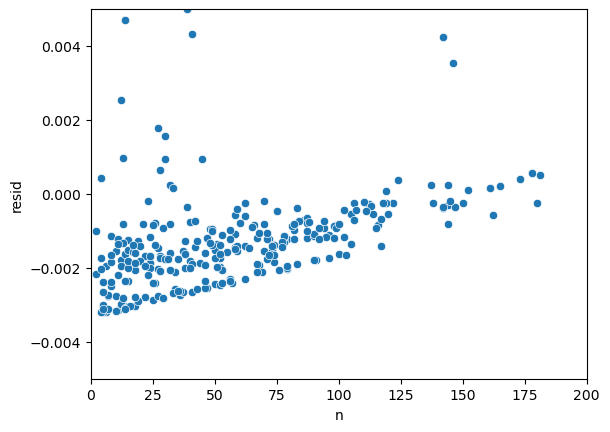

In [26]:
sns.scatterplot(x='n', y='resid', data=df)
plt.xlim(0, 200)
plt.ylim(-0.005, 0.005)
plt.show()

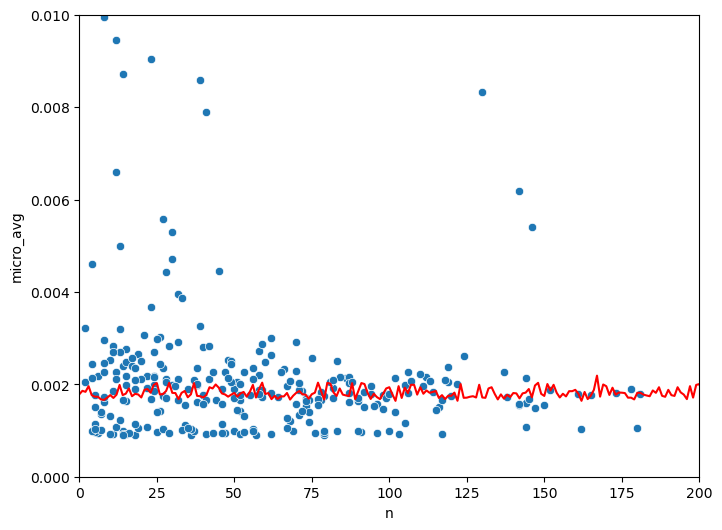

In [27]:
import statsmodels.api as sm
n = df["n"].values
y = df["micro_avg"].values
lowess = sm.nonparametric.lowess(
    y, n, frac=0.3, return_sorted=False
)
df["resid_lowess"] = y - lowess

plt.figure(figsize=(8,6))
sns.scatterplot(x='n', y='micro_avg', data=df)
plt.plot(lowess, color='red')
plt.xlim(0, 200)
plt.ylim(0, 0.01)
plt.show()

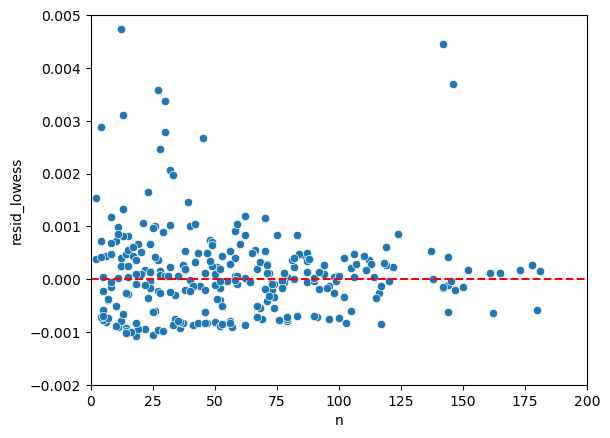

In [28]:
sns.scatterplot(x='n', y='resid_lowess', data=df)
plt.axhline(0, linestyle="--", color='red')
plt.xlim(0, 200)
plt.ylim(-0.002, 0.005)
plt.show()

In [29]:
df['resid_lowess'].sort_values(ascending=False).head(20)

ECM-receptor interaction                                                   0.046635
Hypertrophic cardiomyopathy                                                0.045970
Arrhythmogenic right ventricular cardiomyopathy                            0.026280
Rheumatoid arthritis                                                       0.026067
Basal cell carcinoma                                                       0.024818
Neuroactive ligand-receptor interaction                                    0.019019
Hedgehog signaling pathway                                                 0.016426
Glycosphingolipid biosynthesis - lacto and neolacto series                 0.015534
Hippo signaling pathway - multiple species                                 0.015085
Complement and coagulation cascades                                        0.013863
Adherens junction                                                          0.013459
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate    0

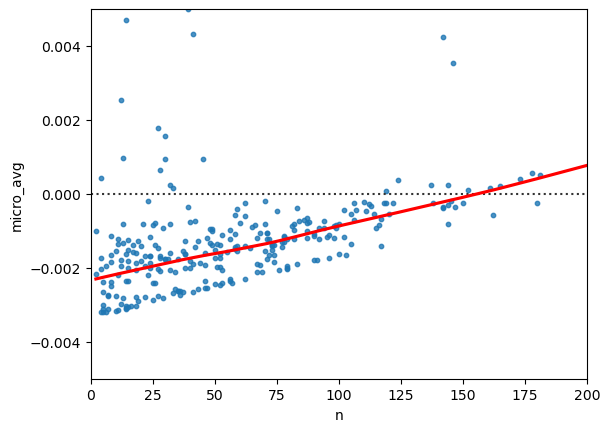

In [30]:
sns.residplot(x='n', y='micro_avg', data=df, lowess=True, line_kws={'color':'red'}, scatter_kws={'s':10})
plt.xlim(0, 200)
plt.ylim(-0.005, 0.005)
plt.show()